    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    Task 11: Implement a program which (a) given a feature model or latent space, (b) a value n, (c) a value m, and (d) a label l
        –   creates a similarity graph, G(V, E), where V corresponds to the images in the database and E contains node pairs Vi , Vj 
            such that, for each subject Vi, Vj is one of the n most similar images in the database in the given space

        –   identifies the most significant m images (relative to the given label l) using personalized PageRank measure. 
            See Huang, S., Li, X., Candan, K. S., Sapino, M. L. (2016). Reducing seed noise in personalized PageRank.
            Social Network Analysis and Mining, 6(1), 1-25.


In [5]:
# todo: fix doc
FEATURE_SPACE_INPUT = input(
"""
Provide a feature model or latent space that was generated using tasks 3 to 6.

Feature space: [color, hog, avgpool, layer3, fc, resnet]

For latent semantics:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_5_svd".
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

N = int(input(
"""
Enter n - the count of most similar images in the database in the given space
"""
))

M = int(input(
"""
Enter m - the count of most significant images in the label to be returned as output of Personalized PageRank Algorithm
"""
))

L = input(
"""
Provide l - the label for which you want to find similar labels
"""
)

In [6]:
# Get feature space
# todo: print reducer and feature space used
# todo: implement for latent space, what distance function to use for latent spaces, same as the feature space??

from utils.database_utils import retrieve

if FEATURE_SPACE_INPUT in ['color', 'hog', 'avgpool', 'layer3', 'fc', 'resnet']:
    feature_space = retrieve(f'{FEATURE_SPACE_INPUT}.pt')
    print(f"Feature Space: {FEATURE_SPACE_INPUT}")
else:
    feature_space_name = FEATURE_SPACE_INPUT.split('_')[1]
    print(f"Feature Space: {feature_space_name}")
    # Load created latent space
    reducer = retrieve(f'{FEATURE_SPACE_INPUT}_reducer.pt')
    print(f"Reducer: {FEATURE_SPACE_INPUT}")
    feature_vectors = retrieve(f'{feature_space_name}.pt')
    feature_space = reducer.reduce_features(feature_vectors)


Feature Space: color


In [7]:
# Create a map from labels to image_ids

label2imageids = {}
for image_id, (label, _) in feature_space.items():
    if label not in label2imageids:
        label2imageids[label] = []

    label2imageids[label].append(image_id)

In [8]:
import networkx as nx
from utils.distance_utils import get_distance_fn, top_k_distance_ranker

G = nx.DiGraph()

for image_id, (label, vector) in feature_space.items():
    node = (image_id, label)
    print(node)
    G.add_node(node)

    # doubt: do we skip the first result? then is it n or n+1?

    top_n = top_k_distance_ranker(
        N,
        vector,
        feature_space,
        get_distance_fn(FEATURE_SPACE_INPUT)
    )

    for _, neighbor_image_id, neighbor_label in top_n[1:]:
        neighbor_node = (neighbor_image_id, neighbor_label)
        G.add_edge(node, neighbor_node, weight = 1/N)


(0, 'Faces')
(2, 'Faces')
(4, 'Faces')
(6, 'Faces')
(8, 'Faces')
(10, 'Faces')
(12, 'Faces')
(14, 'Faces')
(16, 'Faces')
(18, 'Faces')
(20, 'Faces')
(22, 'Faces')
(24, 'Faces')
(26, 'Faces')
(28, 'Faces')
(30, 'Faces')
(32, 'Faces')
(34, 'Faces')
(36, 'Faces')
(38, 'Faces')
(40, 'Faces')
(42, 'Faces')
(44, 'Faces')
(46, 'Faces')
(48, 'Faces')
(50, 'Faces')
(52, 'Faces')
(54, 'Faces')
(56, 'Faces')
(58, 'Faces')
(60, 'Faces')
(62, 'Faces')
(64, 'Faces')
(66, 'Faces')
(68, 'Faces')
(70, 'Faces')
(72, 'Faces')
(74, 'Faces')
(76, 'Faces')
(78, 'Faces')
(80, 'Faces')
(82, 'Faces')
(84, 'Faces')
(86, 'Faces')
(88, 'Faces')
(90, 'Faces')
(92, 'Faces')
(94, 'Faces')
(96, 'Faces')
(98, 'Faces')
(100, 'Faces')
(102, 'Faces')
(104, 'Faces')
(106, 'Faces')
(108, 'Faces')
(110, 'Faces')
(112, 'Faces')
(114, 'Faces')
(116, 'Faces')
(118, 'Faces')
(120, 'Faces')
(122, 'Faces')
(124, 'Faces')
(126, 'Faces')
(128, 'Faces')
(130, 'Faces')
(132, 'Faces')
(134, 'Faces')
(136, 'Faces')
(138, 'Faces')
(140,

In [13]:
# Provide the subset of all imageids under label L for personalization
personalization_map = {(image_id, L): 1/len(label2imageids[L]) for image_id in label2imageids[L]}


# Compute pagerank
pr = nx.pagerank(
    G,
    alpha=0.85,
    personalization=personalization_map,
    weight='weight'
)

In [14]:
# doubt: should the output be only selected from the labels?

label_subset_pr =  {k:v for k, v in pr.items() if k[1] == L}

# Top M significant images relative to the label L
top_m = sorted(label_subset_pr.items(), key=lambda kv: kv[1], reverse=True)[:M]
top_m

[((26, 'Faces'), 0.013143305756577343),
 ((16, 'Faces'), 0.013121288231893668),
 ((234, 'Faces'), 0.010513406116183817),
 ((82, 'Faces'), 0.009831009124352919),
 ((144, 'Faces'), 0.009416426395286167)]

Files already downloaded and verified
27. 	Image ID:  26 		Label:  Faces 		PageRank:  0.013143305756577343


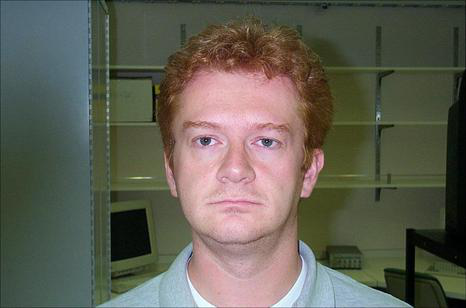

17. 	Image ID:  16 		Label:  Faces 		PageRank:  0.013121288231893668


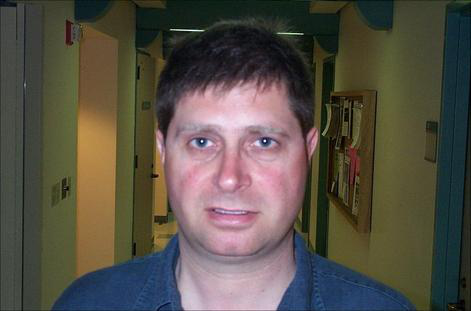

235. 	Image ID:  234 		Label:  Faces 		PageRank:  0.010513406116183817


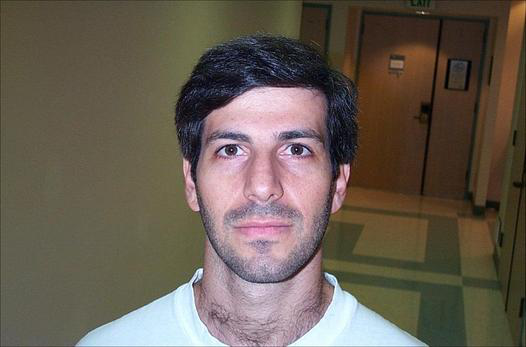

83. 	Image ID:  82 		Label:  Faces 		PageRank:  0.009831009124352919


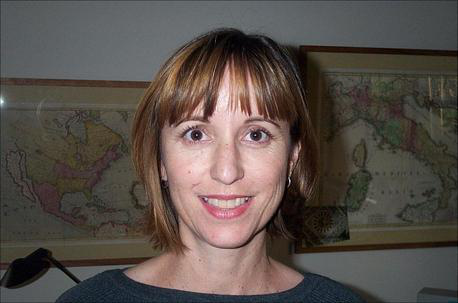

145. 	Image ID:  144 		Label:  Faces 		PageRank:  0.009416426395286167


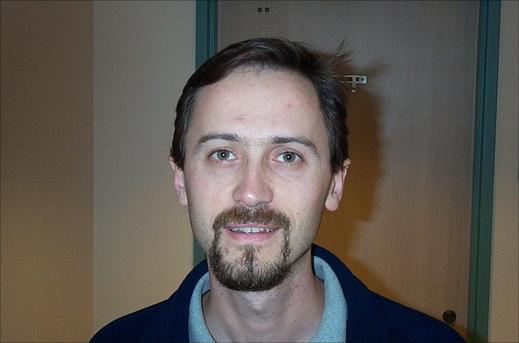

In [15]:
# Display output
# doubt: image_d + 1?
# doubt: pagerank for all images, or only even?

from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

for (image_id, label), pagerank_score in top_m:
    print(str(image_id + 1) + ".", "\tImage ID: ", image_id, "\t\tLabel: ", label, "\t\tPageRank: ", pagerank_score)
    display(dataset[image_id][0])